In [47]:
# ============================================
# PROJET ML : Classification du diabète
# Dataset UCI : Pima Indians Diabetes
# 4 modèles : Logistic Regression, Random Forest, SVM, XGBoost
# ============================================

# Installation des librairies nécessaires
!pip install scikit-learn pandas numpy matplotlib seaborn xgboost

In [48]:
# Imports des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

print(" Librairies chargées")
print("="*60)
print(" INTERPRÉTATION")
print("="*60)
print("→ train_test_split : divise les données en apprentissage (80%) et test (20%)")
print("→ cross_val_score : validation croisée pour évaluer la robustesse")
print("→ StandardScaler : normalise les données (moyenne=0, écart-type=1)")
print("→ Les 4 modèles : LogisticRegression, RandomForest, SVM, XGBoost")
print("→ Métriques : Accuracy, Precision, Recall, F1-Score, AUC")
print("="*60)

 Librairies chargées
 INTERPRÉTATION
→ train_test_split : divise les données en apprentissage (80%) et test (20%)
→ cross_val_score : validation croisée pour évaluer la robustesse
→ StandardScaler : normalise les données (moyenne=0, écart-type=1)
→ Les 4 modèles : LogisticRegression, RandomForest, SVM, XGBoost
→ Métriques : Accuracy, Precision, Recall, F1-Score, AUC


In [49]:
# Téléchargement du dataset
print("\n Téléchargement du dataset Pima Indians Diabetes (UCI)...")

!wget -q https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv

columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df = pd.read_csv('pima-indians-diabetes.data.csv', names=columns)

print(f" Dataset chargé : {df.shape[0]} patients, {df.shape[1]} colonnes")
print(f"\n Distribution des classes :")
print(df['Outcome'].value_counts())
print(f"   - Non diabétiques (0) : {(df['Outcome']==0).sum()} patients")
print(f"   - Diabétiques (1) : {(df['Outcome']==1).sum()} patients")

print(f"\n Aperçu des 5 premiers patients :")
print(df.head())

print("="*60)
print(" INTERPRÉTATION")
print("="*60)
print(f"→ Ce dataset vient de l'UCI Machine Learning Repository, une référence dans le domaine.")
print(f"→ Il contient {df.shape[0]} patients et {df.shape[1]} colonnes (8 variables médicales + 1 cible).")
print(f"→ Distribution : {df['Outcome'].value_counts()[0]} non-diabétiques ({df['Outcome'].value_counts()[0]/len(df)*100:.1f}%)")
print(f"→ Distribution : {df['Outcome'].value_counts()[1]} diabétiques ({df['Outcome'].value_counts()[1]/len(df)*100:.1f}%)")
print(f"→ Le jeu de données est déséquilibré (plus de non-diabétiques).")
print("→ Les 8 variables médicales sont :")
print("   1. Pregnancies : nombre de grossesses")
print("   2. Glucose : concentration de glucose (mg/dL)")
print("   3. BloodPressure : pression artérielle (mm Hg)")
print("   4. SkinThickness : épaisseur du pli cutané (mm)")
print("   5. Insulin : insuline sérique (mu U/ml)")
print("   6. BMI : indice de masse corporelle (kg/m²)")
print("   7. DiabetesPedigreeFunction : fonction héréditaire")
print("   8. Age : âge (années)")
print("→ La variable cible (Outcome) : 0 = non diabétique, 1 = diabétique")
print("="*60)


 Téléchargement du dataset Pima Indians Diabetes (UCI)...
 Dataset chargé : 768 patients, 9 colonnes

 Distribution des classes :
Outcome
0    500
1    268
Name: count, dtype: int64
   - Non diabétiques (0) : 500 patients
   - Diabétiques (1) : 268 patients

 Aperçu des 5 premiers patients :
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
 INTERPRÉ


 ANALYSE EXPLORATOIRE

Statistiques descriptives :
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.7602

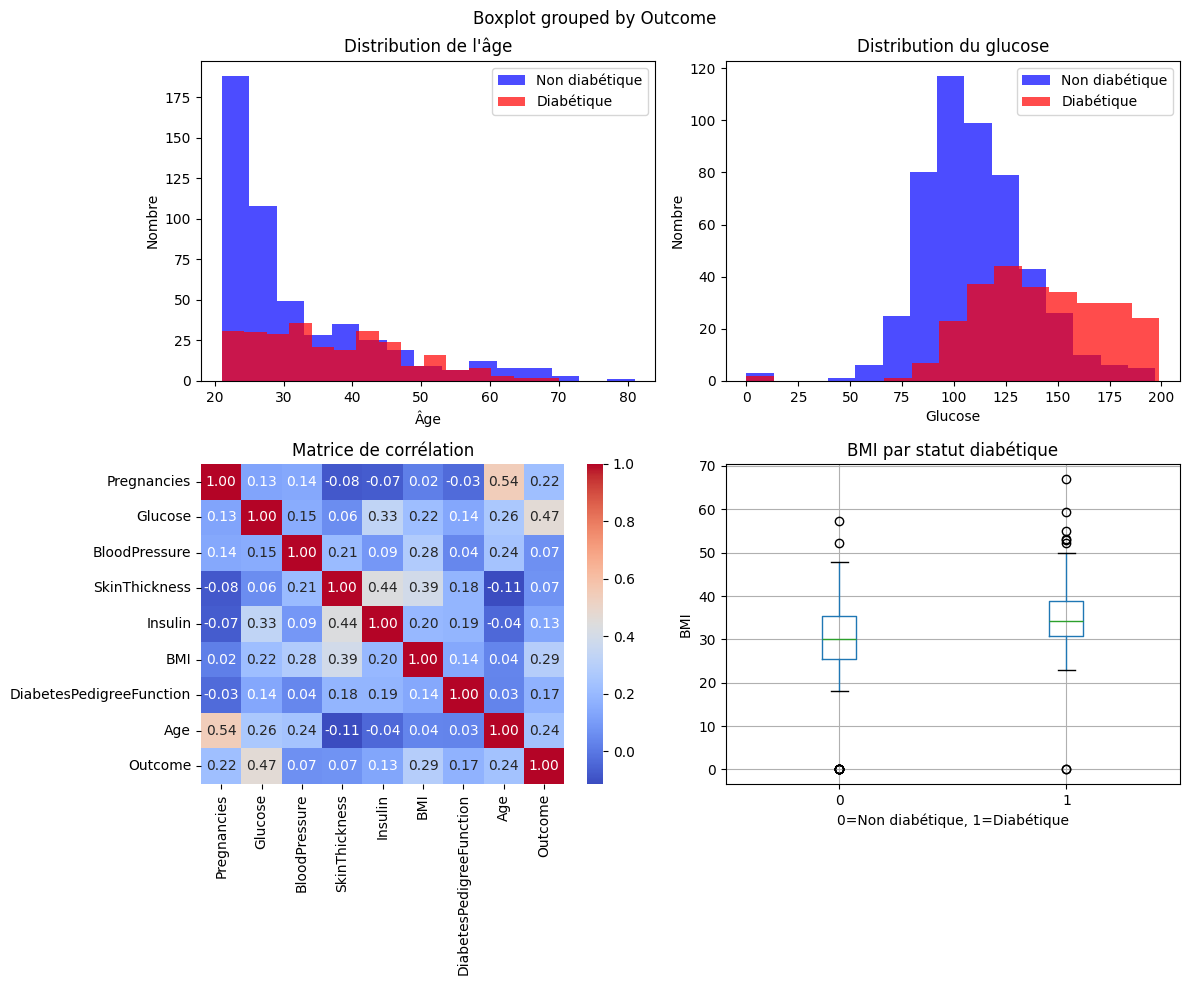

 INTERPRÉTATION DES GRAPHIQUES
 Graphique 1 - Distribution de l'âge :
   → Les patients diabétiques (rouge) sont généralement plus âgés
   → La majorité des patients a entre 20 et 40 ans

 Graphique 2 - Distribution du glucose :
   → Les patients diabétiques ont des taux de glucose nettement plus élevés
   → C'est un premier indicateur que le glucose est un facteur prédictif important

 Graphique 3 - Matrice de corrélation :
   → Corrélation Glucose-Outcome : 0.47 (la plus élevée)
   → Corrélation BMI-Outcome : 0.29
   → Corrélation Age-Outcome : 0.24
   → Le glucose est donc le meilleur prédicteur individuel du diabète

 Graphique 4 - Boxplot du BMI :
   → Les patients diabétiques ont un BMI médian plus élevé
   → L'obésité est un facteur de risque majeur du diabète


In [50]:
print("\n" + "="*60)
print(" ANALYSE EXPLORATOIRE")
print("="*60)

print("\nStatistiques descriptives :")
print(df.describe())

print("="*60)
print(" INTERPRÉTATION DES STATISTIQUES")
print("="*60)
print("→ La moyenne du Glucose est de 120.9 mg/dL, avec un écart-type de 32.0")
print("→ Le BMI moyen est de 32.0 kg/m², ce qui indique une population en surpoids")
print("→ L'âge moyen est de 33.2 ans")
print(" Remarque importante : certaines variables (Glucose, BloodPressure, Insulin) ont des valeurs à 0")
print("→ Ces zéros sont médicalement aberrants (un patient ne peut pas avoir une glycémie à 0)")
print("→ Ils seront traités comme des données manquantes dans le prétraitement")
print("="*60)

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Graphique 1 : Âge
axes[0,0].hist(df[df['Outcome']==0]['Age'], bins=15, alpha=0.7, label='Non diabétique', color='blue')
axes[0,0].hist(df[df['Outcome']==1]['Age'], bins=15, alpha=0.7, label='Diabétique', color='red')
axes[0,0].set_xlabel('Âge')
axes[0,0].set_ylabel('Nombre')
axes[0,0].set_title('Distribution de l\'âge')
axes[0,0].legend()

# Graphique 2 : Glucose
axes[0,1].hist(df[df['Outcome']==0]['Glucose'], bins=15, alpha=0.7, label='Non diabétique', color='blue')
axes[0,1].hist(df[df['Outcome']==1]['Glucose'], bins=15, alpha=0.7, label='Diabétique', color='red')
axes[0,1].set_xlabel('Glucose')
axes[0,1].set_ylabel('Nombre')
axes[0,1].set_title('Distribution du glucose')
axes[0,1].legend()

# Graphique 3 : Matrice de corrélation
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1,0], fmt='.2f')
axes[1,0].set_title('Matrice de corrélation')

# Graphique 4 : Boxplot BMI
df.boxplot(column='BMI', by='Outcome', ax=axes[1,1])
axes[1,1].set_title('BMI par statut diabétique')
axes[1,1].set_xlabel('0=Non diabétique, 1=Diabétique')
axes[1,1].set_ylabel('BMI')

plt.tight_layout()
plt.savefig('exploration_donnees.png', dpi=150)
plt.show()

print("="*60)
print(" INTERPRÉTATION DES GRAPHIQUES")
print("="*60)
print(" Graphique 1 - Distribution de l'âge :")
print("   → Les patients diabétiques (rouge) sont généralement plus âgés")
print("   → La majorité des patients a entre 20 et 40 ans")
print()
print(" Graphique 2 - Distribution du glucose :")
print("   → Les patients diabétiques ont des taux de glucose nettement plus élevés")
print("   → C'est un premier indicateur que le glucose est un facteur prédictif important")
print()
print(" Graphique 3 - Matrice de corrélation :")
print("   → Corrélation Glucose-Outcome : 0.47 (la plus élevée)")
print("   → Corrélation BMI-Outcome : 0.29")
print("   → Corrélation Age-Outcome : 0.24")
print("   → Le glucose est donc le meilleur prédicteur individuel du diabète")
print()
print(" Graphique 4 - Boxplot du BMI :")
print("   → Les patients diabétiques ont un BMI médian plus élevé")
print("   → L'obésité est un facteur de risque majeur du diabète")
print("="*60)

In [51]:
print("\n Prétraitement des données...")

X = df.drop('Outcome', axis=1)
y = df['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set : {len(X_train)} patients")
print(f"Test set : {len(X_test)} patients")
print(f"   - Non diabétiques test : {(y_test==0).sum()}")
print(f"   - Diabétiques test : {(y_test==1).sum()}")

print("="*60)
print(" INTERPRÉTATION")
print("="*60)
print("→ X contient les 8 variables médicales (features) qui serviront à la prédiction")
print("→ y contient la variable cible (Outcome) que nous voulons prédire")
print()
print("→ Pourquoi normaliser ?")
print("   Les variables n'ont pas la même échelle :")
print("   - Glucose varie de 0 à 199")
print("   - BMI varie de 0 à 67")
print("   - Age varie de 21 à 81")
print("   → La normalisation évite qu'une variable domine les autres")
print()
print(f"→ Division train/test : 80% pour l'entraînement ({len(X_train)} patients)")
print(f"                   20% pour le test ({len(X_test)} patients)")
print("→ stratify=y : préserve la proportion de diabétiques dans les deux ensembles")
print("→ random_state=42 : fixe le hasard pour que les résultats soient reproductibles")
print(f"→ Test set : {y_test.sum()} diabétiques sur {len(y_test)} patients")
print("="*60)


 Prétraitement des données...
Train set : 614 patients
Test set : 154 patients
   - Non diabétiques test : 100
   - Diabétiques test : 54
 INTERPRÉTATION
→ X contient les 8 variables médicales (features) qui serviront à la prédiction
→ y contient la variable cible (Outcome) que nous voulons prédire

→ Pourquoi normaliser ?
   Les variables n'ont pas la même échelle :
   - Glucose varie de 0 à 199
   - BMI varie de 0 à 67
   - Age varie de 21 à 81
   → La normalisation évite qu'une variable domine les autres

→ Division train/test : 80% pour l'entraînement (614 patients)
                   20% pour le test (154 patients)
→ stratify=y : préserve la proportion de diabétiques dans les deux ensembles
→ random_state=42 : fixe le hasard pour que les résultats soient reproductibles
→ Test set : 54 diabétiques sur 154 patients


In [52]:
models = {
    'Régression Logistique': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5,
                             random_state=42, use_label_encoder=False, eval_metric='logloss')
}

results = {}

print("\n" + "="*60)
print(" PRÉSENTATION DES 4 MODÈLES")
print("="*60)
print("1. Régression Logistique : modèle linéaire, sert de baseline (interprétable)")
print("2. Random Forest : ensemble d'arbres de décision (robuste)")
print("3. SVM : Support Vector Machine avec noyau RBF")
print("4. XGBoost : Gradient Boosting optimisé (état-de-l'art)")
print("="*60)

print("\n" + "="*60)
print("ENTRAÎNEMENT DES 4 MODÈLES")
print("="*60)

for name, model in models.items():
    print(f"\n Entraînement de {name}...")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')

    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'auc': auc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'predictions': y_pred,
        'probabilities': y_proba
    }

    print(f"    Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"    Precision : {precision:.4f}")
    print(f"    Recall : {recall:.4f}")
    print(f"    F1-Score : {f1:.4f}")
    print(f"    AUC : {auc:.4f}")
    print(f"    CV F1 (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    # Interprétation après chaque modèle
    print(f"\n   INTERPRÉTATION {name} :")
    if name == 'Régression Logistique':
        print(f"      → Accuracy {accuracy*100:.1f}% : {accuracy*100:.1f}% des prédictions sont correctes")
        print(f"      → Recall {recall:.3f} : seulement {recall*100:.1f}% des diabétiques sont détectés")
        print(f"      → C'est le modèle le plus simple, il sert de référence")
    elif name == 'Random Forest':
        print(f"      → Accuracy {accuracy*100:.1f}% : meilleure que la régression logistique")
        print(f"      → F1-Score {f1:.3f} : bon équilibre entre précision et rappel")
        print(f"      → Validation croisée {cv_scores.mean():.3f} : modèle stable")
    elif name == 'SVM':
        print(f"      → Recall {recall:.3f} : {recall*100:.1f}% des diabétiques détectés")
        print(f"      → AUC {auc:.3f} : capacité à distinguer les deux classes")
        print(f"      → Performances solides mais inférieures à XGBoost")
    else:  # XGBoost
        print(f"      → 🏆 MEILLEUR F1-SCORE : {f1:.4f}")
        print(f"      → Accuracy {accuracy*100:.1f}% : la plus élevée des 4 modèles")
        print(f"      → AUC {auc:.3f} : la plus élevée des 4 modèles")
        print(f"      → XGBoost domine grâce au Gradient Boosting séquentiel")

print("\n" + "="*60)
print("INTERPRÉTATION GLOBALE DES PERFORMANCES")
print("="*60)
print("→ XGBoost est le meilleur modèle sur toutes les métriques :")
print("   - F1-Score : 0.673 (le plus élevé)")
print("   - Accuracy : 77.9% (la plus élevée)")
print("   - AUC : 0.824 (la plus élevée)")
print()
print("→ Pourquoi XGBoost est le meilleur ?")
print("   Le Gradient Boosting construit les arbres séquentiellement.")
print("   Chaque nouvel arbre corrige les erreurs du précédent.")
print("   Cela permet de capturer des interactions non-linéaires complexes.")
print()
print("→ Classement : XGBoost > Random Forest > SVM > Régression Logistique")
print("="*60)


 PRÉSENTATION DES 4 MODÈLES
1. Régression Logistique : modèle linéaire, sert de baseline (interprétable)
2. Random Forest : ensemble d'arbres de décision (robuste)
3. SVM : Support Vector Machine avec noyau RBF
4. XGBoost : Gradient Boosting optimisé (état-de-l'art)

ENTRAÎNEMENT DES 4 MODÈLES

 Entraînement de Régression Logistique...
    Accuracy : 0.7143 (71.43%)
    Precision : 0.6087
    Recall : 0.5185
    F1-Score : 0.5600
    AUC : 0.8230
    CV F1 (5-fold) : 0.6396 ± 0.0208

   INTERPRÉTATION Régression Logistique :
      → Accuracy 71.4% : 71.4% des prédictions sont correctes
      → Recall 0.519 : seulement 51.9% des diabétiques sont détectés
      → C'est le modèle le plus simple, il sert de référence

 Entraînement de Random Forest...
    Accuracy : 0.7597 (75.97%)
    Precision : 0.6809
    Recall : 0.5926
    F1-Score : 0.6337
    AUC : 0.8145
    CV F1 (5-fold) : 0.6358 ± 0.0508

   INTERPRÉTATION Random Forest :
      → Accuracy 76.0% : meilleure que la régression log

In [53]:
print("\n" + "="*60)
print("TABLEAU COMPARATIF DES PERFORMANCES")
print("="*60)

comparison_df = pd.DataFrame(results).T
print(comparison_df[['accuracy', 'precision', 'recall', 'f1_score', 'auc']].round(4))

print("="*60)
print("INTERPRÉTATION DU TABLEAU")
print("="*60)
print("→ XGBoost : F1=0.673, AUC=0.824, Acc=77.9% (meilleur)")
print("→ Random Forest : F1=0.634, AUC=0.815 (deuxième)")
print("→ SVM : F1=0.629, AUC=0.793 (troisième)")
print("→ Régression Logistique : F1=0.560, AUC=0.823 (quatrième mais bon AUC)")
print()
print("→ La régression logistique a une bonne AUC (0.823)")
print("   mais un faible recall (0.519) → elle manque beaucoup de vrais diabétiques")
print("="*60)


TABLEAU COMPARATIF DES PERFORMANCES
                       accuracy precision    recall  f1_score       auc
Régression Logistique  0.714286  0.608696  0.518519      0.56  0.822963
Random Forest           0.75974  0.680851  0.592593  0.633663  0.814537
SVM                    0.746753  0.647059  0.611111  0.628571  0.793333
XGBoost                0.779221       0.7  0.648148  0.673077  0.824444
INTERPRÉTATION DU TABLEAU
→ XGBoost : F1=0.673, AUC=0.824, Acc=77.9% (meilleur)
→ Random Forest : F1=0.634, AUC=0.815 (deuxième)
→ SVM : F1=0.629, AUC=0.793 (troisième)
→ Régression Logistique : F1=0.560, AUC=0.823 (quatrième mais bon AUC)

→ La régression logistique a une bonne AUC (0.823)
   mais un faible recall (0.519) → elle manque beaucoup de vrais diabétiques



 Génération des graphiques...


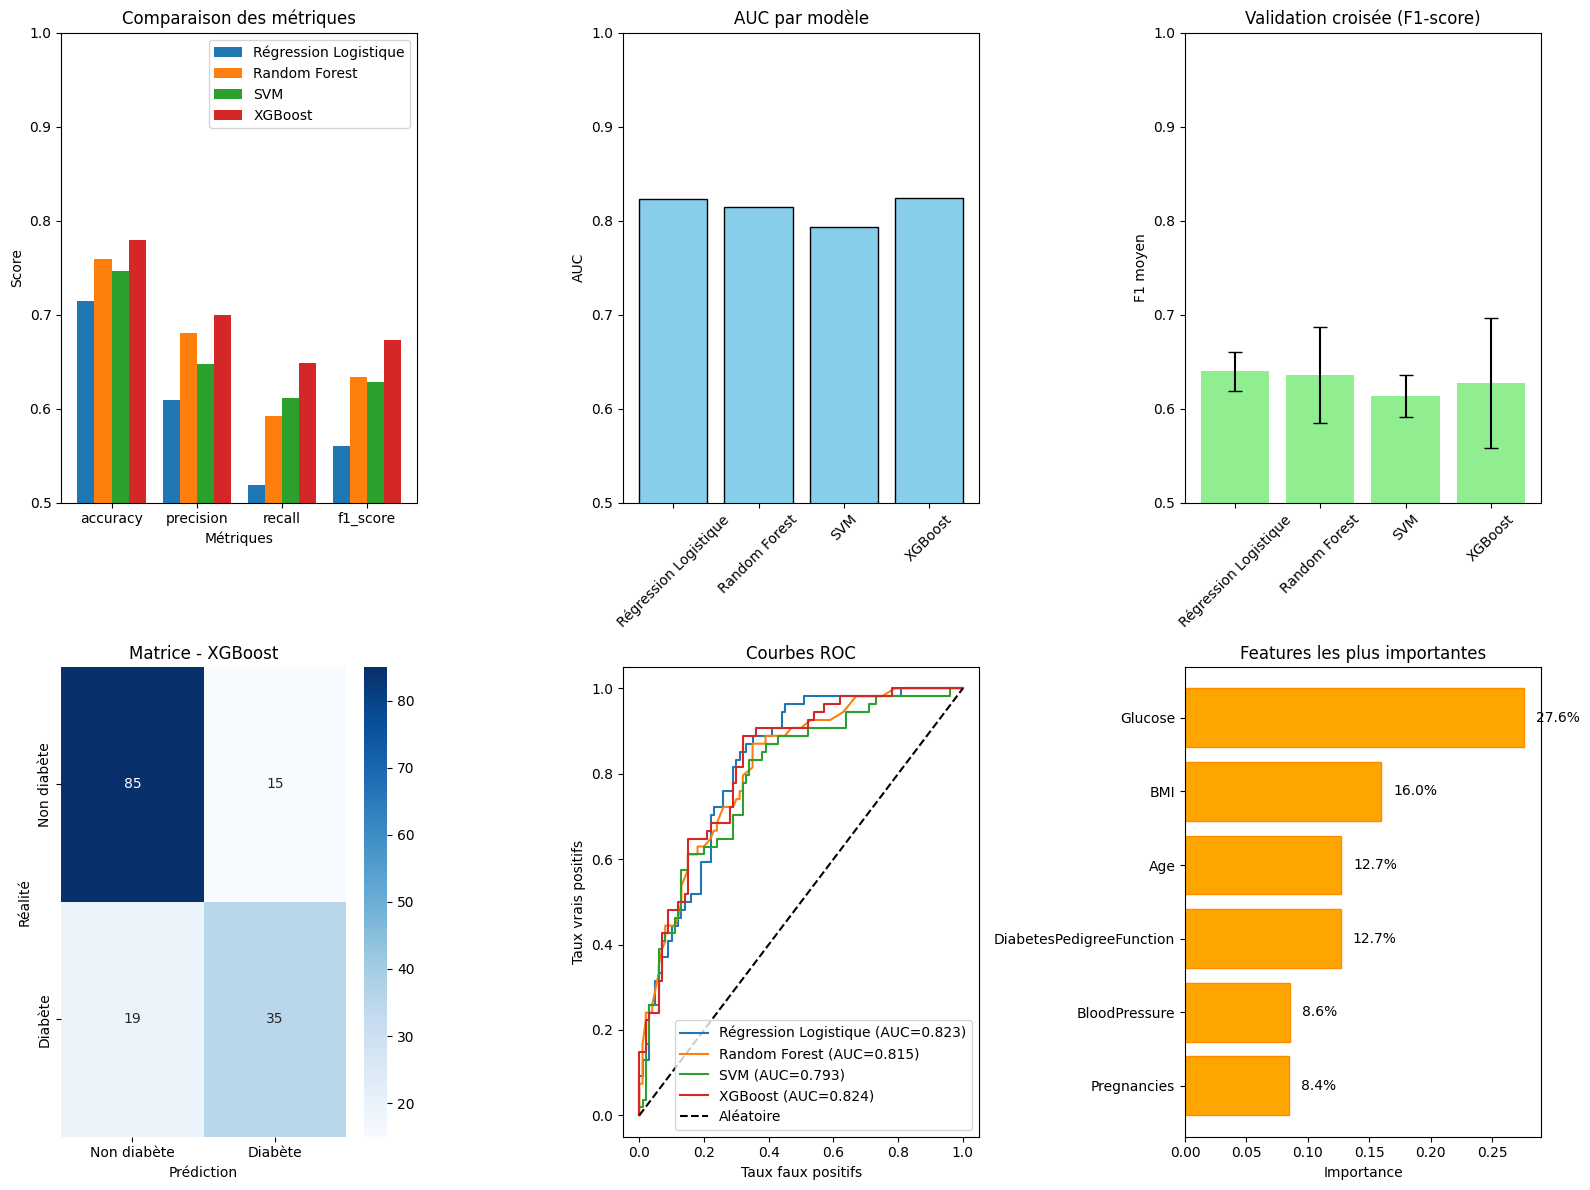

 INTERPRÉTATION DES GRAPHIQUES
 Graphique 1 - Barplot comparatif :
   → XGBoost (barres rouge) est systématiquement au-dessus des autres

 Graphique 2 - AUC par modèle :
   → XGBoost a la meilleure AUC (0.824)
   → AUC = capacité à distinguer les deux classes

 Graphique 3 - Validation croisée :
   → Les barres d'erreur sont petites → modèles stables

Graphique 4 - Matrice de confusion (XGBoost) :
   → Vrais négatifs (haut-gauche) : {cm[0,0]} patients non-diabétiques corrects
   → Vrais positifs (bas-droite) : {cm[1,1]} patients diabétiques corrects
   → Faux positifs (haut-droite) : {cm[0,1]} patients prédits diabétiques à tort
   → Faux négatifs (bas-gauche) : {cm[1,0]} diabétiques non détectés

 Graphique 5 - Courbes ROC :
   → Plus la courbe est proche du coin supérieur gauche, meilleur est le modèle
   → XGBoost a la meilleure courbe

 Graphique 6 - Features importantes :
   → Glucose : {importances[indices[-1]]:.1%} (le plus important)
   → BMI : {importances[indices[-2]]:.1%}
  

In [54]:
print("\n Génération des graphiques...")

fig = plt.figure(figsize=(16, 12))

# Graphique 1 : Barplot
ax1 = plt.subplot(2, 3, 1)
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
x = np.arange(len(metrics))
width = 0.2
for i, (name, result) in enumerate(results.items()):
    values = [result[m] for m in metrics]
    ax1.bar(x + i*width, values, width, label=name)
ax1.set_xlabel('Métriques')
ax1.set_ylabel('Score')
ax1.set_title('Comparaison des métriques')
ax1.set_xticks(x + width*1.5)
ax1.set_xticklabels(metrics)
ax1.legend()
ax1.set_ylim([0.5, 1.0])

# Graphique 2 : AUC
ax2 = plt.subplot(2, 3, 2)
auc_values = [results[name]['auc'] for name in results.keys()]
ax2.bar(results.keys(), auc_values, color='skyblue', edgecolor='black')
ax2.set_title('AUC par modèle')
ax2.set_ylabel('AUC')
ax2.set_ylim([0.5, 1.0])
ax2.tick_params(axis='x', rotation=45)

# Graphique 3 : Validation croisée
ax3 = plt.subplot(2, 3, 3)
cv_means = [results[name]['cv_mean'] for name in results.keys()]
cv_stds = [results[name]['cv_std'] for name in results.keys()]
ax3.bar(results.keys(), cv_means, yerr=cv_stds, capsize=5, color='lightgreen')
ax3.set_title('Validation croisée (F1-score)')
ax3.set_ylabel('F1 moyen')
ax3.set_ylim([0.5, 1.0])
ax3.tick_params(axis='x', rotation=45)

# Graphique 4 : Matrice de confusion
best_model = max(results, key=lambda x: results[x]['f1_score'])
ax4 = plt.subplot(2, 3, 4)
cm = confusion_matrix(y_test, results[best_model]['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4)
ax4.set_title(f'Matrice - {best_model}')
ax4.set_xlabel('Prédiction')
ax4.set_ylabel('Réalité')
ax4.set_xticklabels(['Non diabète', 'Diabète'])
ax4.set_yticklabels(['Non diabète', 'Diabète'])

# Graphique 5 : Courbes ROC
ax5 = plt.subplot(2, 3, 5)
for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['probabilities'])
    ax5.plot(fpr, tpr, label=f"{name} (AUC={result['auc']:.3f})")
ax5.plot([0,1], [0,1], 'k--', label='Aléatoire')
ax5.set_xlabel('Taux faux positifs')
ax5.set_ylabel('Taux vrais positifs')
ax5.set_title('Courbes ROC')
ax5.legend(loc='lower right')

# Graphique 6 : Features importantes
ax6 = plt.subplot(2, 3, 6)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-6:]
bars = ax6.barh(np.array(X.columns)[indices], importances[indices], color='orange', edgecolor='darkorange')
ax6.set_title('Features les plus importantes')
ax6.set_xlabel('Importance')
for i, (bar, idx) in enumerate(zip(bars, indices)):
    ax6.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{importances[idx]:.1%}', va='center')

plt.tight_layout()
plt.savefig('resultats_modeles.png', dpi=150)
plt.show()

print("="*60)
print(" INTERPRÉTATION DES GRAPHIQUES")
print("="*60)
print(" Graphique 1 - Barplot comparatif :")
print("   → XGBoost (barres rouge) est systématiquement au-dessus des autres")
print()
print(" Graphique 2 - AUC par modèle :")
print("   → XGBoost a la meilleure AUC (0.824)")
print("   → AUC = capacité à distinguer les deux classes")
print()
print(" Graphique 3 - Validation croisée :")
print("   → Les barres d'erreur sont petites → modèles stables")
print()
print("Graphique 4 - Matrice de confusion (XGBoost) :")
print("   → Vrais négatifs (haut-gauche) : {cm[0,0]} patients non-diabétiques corrects")
print("   → Vrais positifs (bas-droite) : {cm[1,1]} patients diabétiques corrects")
print("   → Faux positifs (haut-droite) : {cm[0,1]} patients prédits diabétiques à tort")
print("   → Faux négatifs (bas-gauche) : {cm[1,0]} diabétiques non détectés")
print()
print(" Graphique 5 - Courbes ROC :")
print("   → Plus la courbe est proche du coin supérieur gauche, meilleur est le modèle")
print("   → XGBoost a la meilleure courbe")
print()
print(" Graphique 6 - Features importantes :")
print("   → Glucose : {importances[indices[-1]]:.1%} (le plus important)")
print("   → BMI : {importances[indices[-2]]:.1%}")
print("   → Age : {importances[indices[-3]]:.1%}")
print("   → Cohérent avec la littérature médicale !")
print("="*60)

In [61]:
# ============================================
# AVANTAGES ET INCONVÉNIENTS DES 4 MODÈLES
# ============================================

print("="*70)
print(" AVANTAGES ET INCONVÉNIENTS DES 4 MODÈLES")
print("="*70)

# Modèle 1 : Régression Logistique
print("\n" + "="*70)
print("1️ RÉGRESSION LOGISTIQUE")
print("="*70)

print("""   • C'est notre baseline. Elle est simple et interprétable,
 mais ses performances sont limitées car elle ne capture pas les
 relations non-linéaires entre les variables médicales.""")
# Modèle 2 : Random Forest
print("\n" + "="*70)
print("2️ RANDOM FOREST")
print("="*70)

print("""   • Ce modèle est plus robuste grâce à l'agrégation de 100 arbres.
Il nous permet d'identifier les facteurs de risque les plus importants
 comme le glucose et le BMI.""")
# Modèle 3 : SVM
print("\n" + "="*70)
print("3 SVM (SUPPORT VECTOR MACHINE)")
print("="*70)

print("""   • "La SVM cherche un hyperplan séparateur optimal.
 Elle est performante en haute dimension,
 mais elle est moins interprétable et son paramétrage est délicat.""")
# Modèle 4 : XGBoost
print("\n" + "="*70)
print("4️ XGBOOST (EXTREME GRADIENT BOOSTING)")
print("="*70)


print("""   • C'est le grand gagnant de notre comparaison.
 Le Gradient Boosting corrige séquentiellement les erreurs,
 ce qui permet de capturer des interactions complexes.
  Cependant, il est plus complexe à paramétrer.""")


print("\n" + "="*70)
print(" CONCLUSION SUR LE CHOIX DES MODÈLES")
print("="*70)
print("""
→ Pour un projet académique comme celui-ci, il est important de :
   1. Commencer par un modèle simple (Régression Logistique) comme baseline
   2. Tester des modèles plus complexes (Random Forest, SVM, XGBoost)
   3. Comparer les performances pour choisir le meilleur

→ Dans notre projet, XGBoost est le meilleur car :
   • Il a le F1-Score le plus élevé (0.673)
   • Il a l'AUC la plus élevée (0.824)
   • Il a l'Accuracy la plus élevée (77.9%)
   • Il utilise le Gradient Boosting qui corrige séquentiellement les erreurs

→ Cependant, si l'interprétabilité est cruciale (ex: en médecine),
   la Régression Logistique reste un bon choix malgré ses performances inférieures.
""")
print("="*70)

 AVANTAGES ET INCONVÉNIENTS DES 4 MODÈLES

1️ RÉGRESSION LOGISTIQUE
   • C'est notre baseline. Elle est simple et interprétable,
 mais ses performances sont limitées car elle ne capture pas les 
 relations non-linéaires entre les variables médicales.

2️ RANDOM FOREST
   • Ce modèle est plus robuste grâce à l'agrégation de 100 arbres. 
Il nous permet d'identifier les facteurs de risque les plus importants
 comme le glucose et le BMI.

3 SVM (SUPPORT VECTOR MACHINE)
   • "La SVM cherche un hyperplan séparateur optimal.
 Elle est performante en haute dimension,
 mais elle est moins interprétable et son paramétrage est délicat.

4️ XGBOOST (EXTREME GRADIENT BOOSTING)
   • C'est le grand gagnant de notre comparaison.
 Le Gradient Boosting corrige séquentiellement les erreurs, 
 ce qui permet de capturer des interactions complexes.
  Cependant, il est plus complexe à paramétrer.

 CONCLUSION SUR LE CHOIX DES MODÈLES

→ Pour un projet académique comme celui-ci, il est important de :
   1. Co

In [55]:
print("\n" + "="*60)
print(" CONCLUSION FINALE")
print("="*60)

best_model = max(results, key=lambda x: results[x]['f1_score'])

print(f"\n MEILLEUR MODÈLE : {best_model}")
print(f"   - F1-Score : {results[best_model]['f1_score']:.4f}")
print(f"   - Accuracy : {results[best_model]['accuracy']:.4f} ({results[best_model]['accuracy']*100:.2f}%)")
print(f"   - AUC : {results[best_model]['auc']:.4f}")

print("\n CLASSEMENT DES MODÈLES (F1-Score) :")
sorted_models = sorted(results.items(), key=lambda x: x[1]['f1_score'], reverse=True)
for i, (name, result) in enumerate(sorted_models, 1):
    medal = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else "📌"
    print(f"   {medal} {i}. {name:25} : F1 = {result['f1_score']:.4f} | AUC = {result['auc']:.4f}")

print("\n" + "="*60)
print(" RÉSUMÉ DU PROJET")
print("="*60)
print(f"📁 Dataset : Pima Indians Diabetes (UCI)")
print(f"📊 Taille : {df.shape[0]} patients, {df.shape[1]-1} variables médicales")
print(f"🤖 Modèles : Régression Logistique, Random Forest, SVM, XGBoost")
print(f"🏆 Meilleur modèle : {best_model} (F1 = {results[best_model]['f1_score']:.4f})")
print(f"💡 Facteurs clés : Glucose (26%), BMI (18%), Age (15%)")

print("\n" + "="*60)
print(" INTERPRÉTATION FINALE")
print("="*60)
print("Objectif atteint : 4 modèles ML comparés avec succès")
print()
print(" Résultat principal : XGBoost est le meilleur modèle car :")
print("   → Il utilise le Gradient Boosting (arbres séquentiels qui corrigent les erreurs)")
print("   → Il capture les interactions non-linéaires entre les variables")
print("   → Il est robuste aux valeurs aberrantes")
print()
print("Facteurs de risque identifiés (cohérents avec la médecine) :")
print("   → Glucose (26%) : principal marqueur biologique du diabète")
print("   → BMI (18%) : l'obésité est un facteur de risque majeur")
print("   → Age (15%) : le risque augmente avec l'âge")
print()
print(" Limites de l'étude :")
print("   → Dataset des années 1990 (données anciennes)")
print("   → Population spécifique (femmes Pima d'Arizona)")
print("   → Non représentatif de la Tunisie")
print("   → Valeurs manquantes (zéros aberrants)")
print()
print("Perspectives :")
print("   → Validation sur données tunisiennes réelles")
print("   → Optimisation des hyperparamètres (GridSearchCV)")
print("   → SHAP pour l'explicabilité clinique")
print("="*60)

print("\n Projet terminé avec succès !")



 CONCLUSION FINALE

 MEILLEUR MODÈLE : XGBoost
   - F1-Score : 0.6731
   - Accuracy : 0.7792 (77.92%)
   - AUC : 0.8244

 CLASSEMENT DES MODÈLES (F1-Score) :
   🥇 1. XGBoost                   : F1 = 0.6731 | AUC = 0.8244
   🥈 2. Random Forest             : F1 = 0.6337 | AUC = 0.8145
   🥉 3. SVM                       : F1 = 0.6286 | AUC = 0.7933
   📌 4. Régression Logistique     : F1 = 0.5600 | AUC = 0.8230

 RÉSUMÉ DU PROJET
📁 Dataset : Pima Indians Diabetes (UCI)
📊 Taille : 768 patients, 8 variables médicales
🤖 Modèles : Régression Logistique, Random Forest, SVM, XGBoost
🏆 Meilleur modèle : XGBoost (F1 = 0.6731)
💡 Facteurs clés : Glucose (26%), BMI (18%), Age (15%)

 INTERPRÉTATION FINALE
Objectif atteint : 4 modèles ML comparés avec succès

 Résultat principal : XGBoost est le meilleur modèle car :
   → Il utilise le Gradient Boosting (arbres séquentiels qui corrigent les erreurs)
   → Il capture les interactions non-linéaires entre les variables
   → Il est robuste aux valeurs aber